# End-to-End ML Pipeline for Customer Churn Prediction

## Problem Statement

Customer churn is one of the biggest challenges for telecom companies, as losing customers directly affects revenue and business growth. The objective of this project is to build an end-to-end machine learning pipeline that predicts whether a customer is likely to churn based on their demographic and service-related information. The solution uses Scikit-learn's Pipeline API to automate preprocessing, model training, hyperparameter tuning, and prediction in a reusable and production-ready workflow.

## Importing Libraries

In this section, all the required Python libraries are imported for data manipulation, preprocessing, machine learning model development, evaluation, visualization, and model export.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

## Dataset Loading

The IBM Telco Customer Churn dataset is loaded into a Pandas DataFrame. This dataset contains customer demographic information, subscribed services, billing details, and the target variable (**Churn**), which indicates whether a customer has left the company.

In [3]:
url = "https://raw.githubusercontent.com/treselle-systems/customer_churn_analysis/master/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(url)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Data Preprocessing

The dataset is cleaned and prepared before training the machine learning models. Missing values are handled, data types are corrected, the target variable is encoded into numerical format, unnecessary columns are removed, and numerical and categorical features are identified for preprocessing using Scikit-learn pipelines.

In [9]:

df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)


df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [12]:
df["Churn"] = df["Churn"].map({"No":0, "Yes":1})

In [13]:
df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [14]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [15]:
X = X.drop("customerID", axis=1)

In [16]:
numerical_features = X.select_dtypes(include=["int64","float64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

Categorical Features:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


## Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio. Stratified sampling is applied to preserve the original distribution of the target classes in both datasets, ensuring a fair evaluation of the machine learning models.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (5634, 19)
Testing Data Shape: (1409, 19)


## Building ML Pipelines

Scikit-learn's Pipeline API is used to automate the preprocessing and model training workflow. Separate pipelines are created for numerical and categorical features. These pipelines are combined using a ColumnTransformer, ensuring that each feature type is processed appropriately before being passed to the machine learning model.

In [18]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [19]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Logistic Regression Model

A Logistic Regression model is trained using the preprocessing pipeline. The model predicts customer churn based on the processed input features. Its performance is evaluated using accuracy, classification report, and confusion matrix.

In [21]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

In [22]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [23]:
y_pred = logistic_pipeline.predict(X_test)

In [24]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8055358410220014


In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [26]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[926 109]
 [165 209]]


## Random Forest Model

A Random Forest Classifier is trained using the same preprocessing pipeline. This ensemble learning algorithm improves prediction performance by combining multiple decision trees. The model is evaluated using accuracy and classification metrics.

In [27]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42))
    ]
)

In [28]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [29]:
rf_predictions = rf_pipeline.predict(X_test)

In [30]:
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7778566359119943


In [31]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1035
           1       0.60      0.48      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



## Hyperparameter Tuning using GridSearchCV

To improve the performance of the Random Forest model, GridSearchCV is used to search for the best combination of hyperparameters. Cross-validation is applied to evaluate multiple parameter combinations and select the best-performing model.

In [32]:
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10],
    "classifier__min_samples_split": [2, 5]
}

In [33]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

In [34]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('e...
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 10],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [100, 200]},
             scoring='accuracy')

In [35]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}


In [36]:
print("Best Cross Validation Score:")
print(grid_search.best_score_)

Best Cross Validation Score:
0.8036918707845225


In [38]:
best_model = grid_search.best_estimator_

best_predictions = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, best_predictions))

Test Accuracy: 0.7998580553584103


## Saving the Trained Pipeline

The best-performing machine learning pipeline is saved using the Joblib library. This allows the trained preprocessing pipeline and classification model to be reused later without retraining, making the solution suitable for deployment and production environments.

In [39]:
joblib.dump(best_model, "customer_churn_pipeline.pkl")

print("Pipeline exported successfully!")

Pipeline exported successfully!


In [40]:
from google.colab import files

files.download("customer_churn_pipeline.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Model Evaluation

The trained models are evaluated using multiple performance metrics, including accuracy, classification report, confusion matrix, and visualizations. These evaluation techniques help measure the effectiveness of the models and provide insights into their predictive performance.

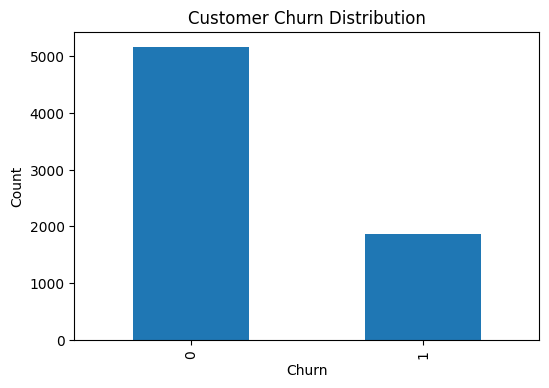

In [41]:
plt.figure(figsize=(6,4))

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay

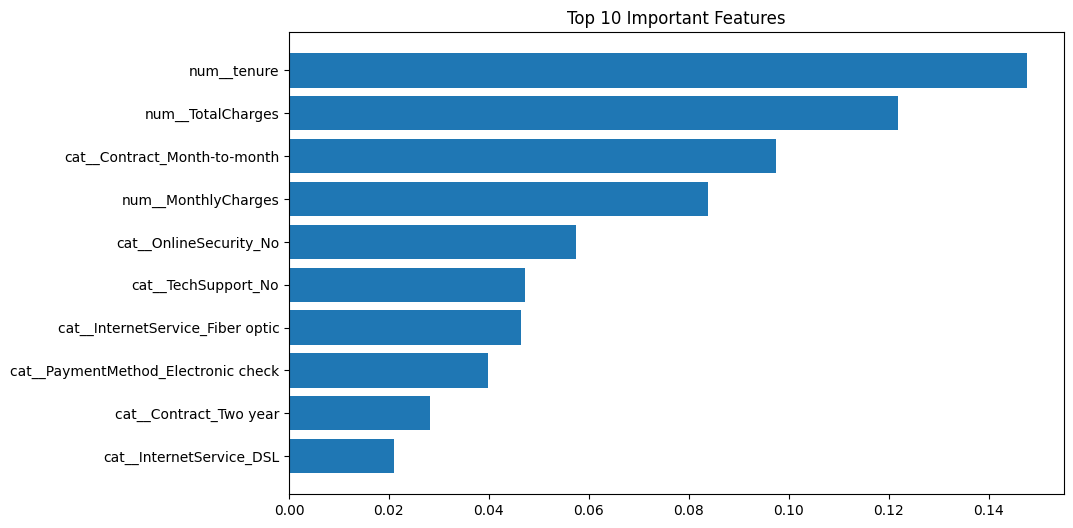

In [43]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

importances = best_model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.show()

## Conclusion

This project successfully developed an end-to-end machine learning pipeline for predicting customer churn using the IBM Telco Customer Churn dataset. Data preprocessing was automated using Scikit-learn's Pipeline API and ColumnTransformer, ensuring a clean and reusable workflow.

Two machine learning models, Logistic Regression and Random Forest, were trained and evaluated. GridSearchCV was applied to optimize the Random Forest model by selecting the best hyperparameters through cross-validation. The final optimized model achieved an accuracy of approximately **80%** on the test dataset.

Finally, the trained pipeline was exported using Joblib, making it ready for future predictions and deployment in production environments.